# Drift Detection Timing Analysis
This notebook analyzes and compares the average drift detection timing for each technique using experiment timing data from the timing summary CSV.

In [37]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

In [38]:
# Load Timing Data from CSV and JSON
csv_file_path = '../comparison_results/timing_summary.csv'
json_file_path = '../comparison_results/experiment_timing_results.json'

# Load CSV data into a DataFrame
timing_data = pd.read_csv(csv_file_path)

# Load JSON data into a dictionary
with open(json_file_path, 'r') as json_file:
    experiment_data = json.load(json_file)

In [39]:
# Extract Drift Detection Timing per Technique
drift_detection_data = timing_data[timing_data['phase'] == 'drift_detection']
grouped_data = drift_detection_data.groupby('technique')['duration_seconds']

In [40]:
timing_data.type.unique()

array(['technique_timing', 'phase_timing', 'batch_total', 'technique_avg'],
      dtype=object)

In [41]:
# Compute Average Drift Detection Time per Technique
average_drift_detection_time = grouped_data.mean().sort_values()
print(average_drift_detection_time)

technique
JSDDM       1.879309
HDDDM       2.158357
KSDDM_90    7.297740
KSDDM_95    8.097768
Name: duration_seconds, dtype: float64


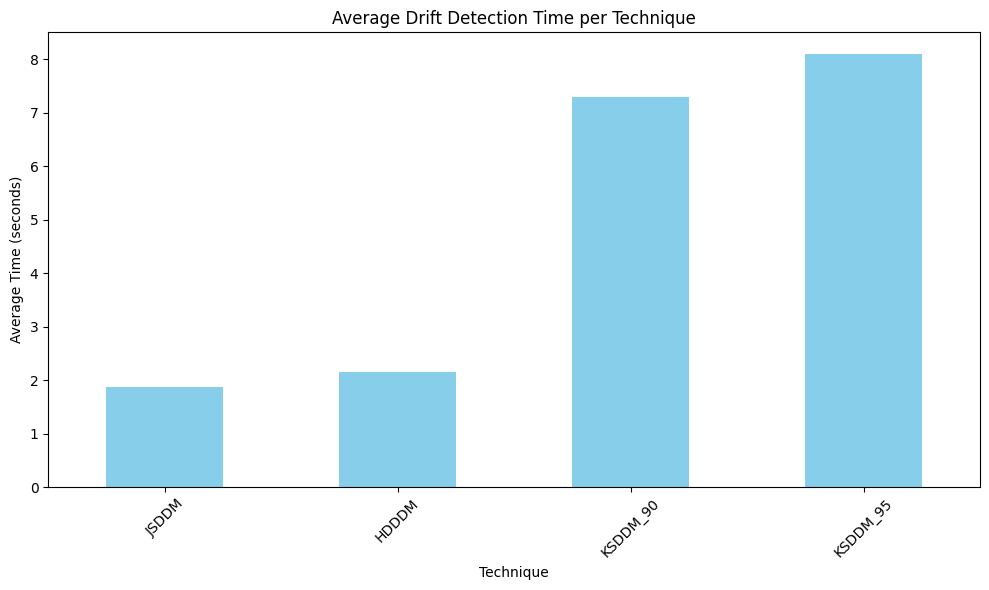

In [42]:
# Visualize Average Drift Detection Time per Technique
plt.figure(figsize=(10, 6))
average_drift_detection_time.plot(kind='bar', color='skyblue')
plt.title('Average Drift Detection Time per Technique')
plt.xlabel('Technique')
plt.ylabel('Average Time (seconds)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('./images/average_drift_detection_time_per_technique_single_run.png')
plt.show()

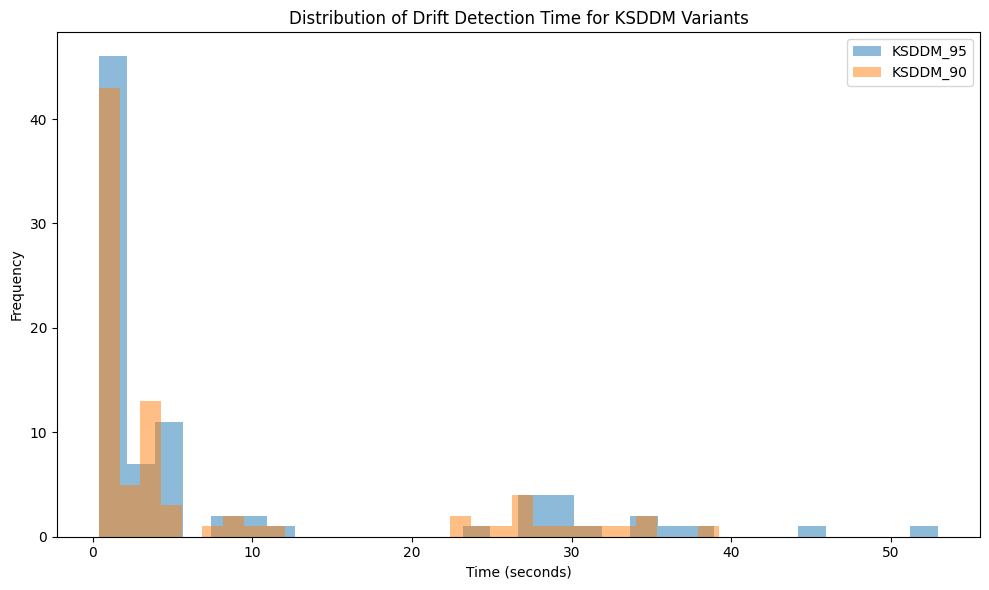

In [43]:
# Investigate KSDDM Timing
ksddm_data = drift_detection_data[drift_detection_data['technique'].str.contains('KSDDM')]

# Plot distribution of KSDDM timing
plt.figure(figsize=(10, 6))
for technique in ksddm_data['technique'].unique():
    subset = ksddm_data[ksddm_data['technique'] == technique]
    plt.hist(subset['duration_seconds'], bins=30, alpha=0.5, label=technique)

plt.title('Distribution of Drift Detection Time for KSDDM Variants')
plt.xlabel('Time (seconds)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('./images/ksddm_timing_distribution_single_run.png')
plt.show()

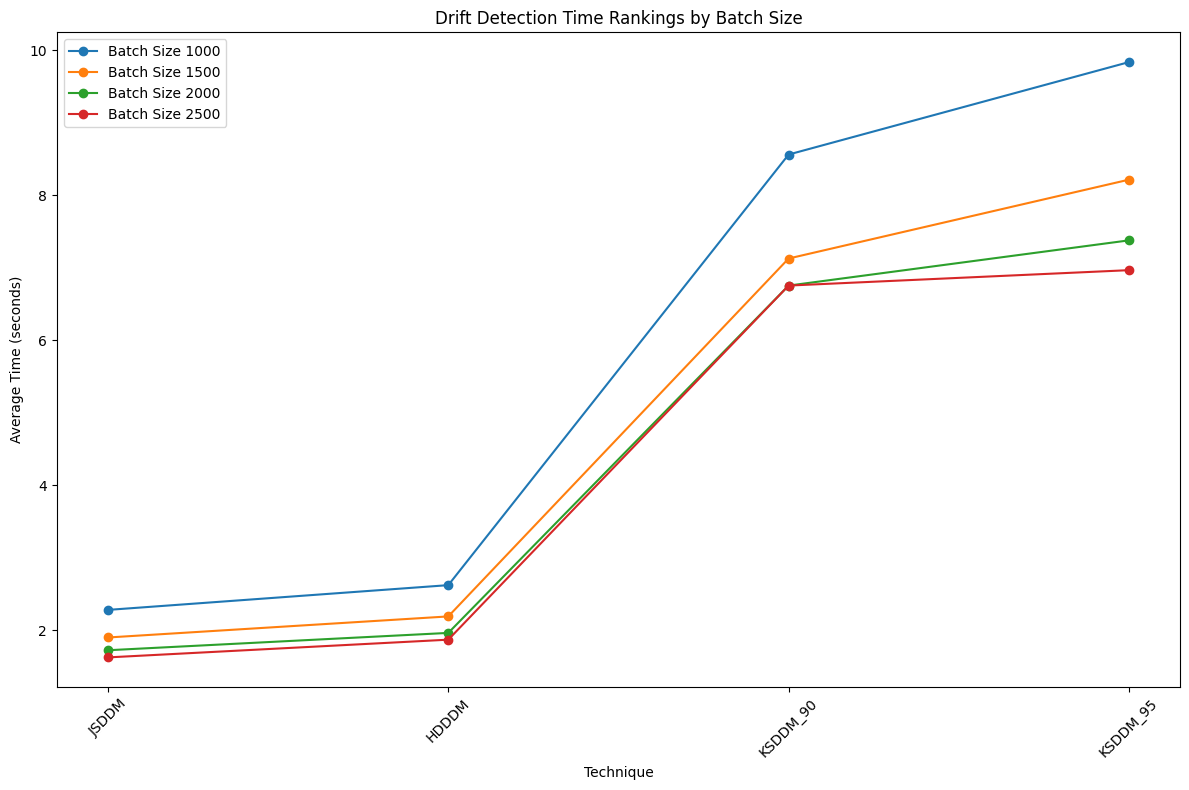

In [44]:
# Analyze Technique Rankings by Batch Size
batch_size_ranking = drift_detection_data[drift_detection_data['batch_size'] != 'ALL'].groupby(['batch_size', 'technique'])['duration_seconds'].mean().reset_index()
batch_size_ranking = batch_size_ranking.sort_values(['batch_size', 'duration_seconds'])

# Plot rankings for each batch size
unique_batch_sizes = batch_size_ranking['batch_size'].unique()
plt.figure(figsize=(12, 8))
for batch_size in unique_batch_sizes:
    subset = batch_size_ranking[batch_size_ranking['batch_size'] == batch_size]
    plt.plot(subset['technique'], subset['duration_seconds'], marker='o', label=f'Batch Size {batch_size}')

plt.title('Drift Detection Time Rankings by Batch Size')
plt.xlabel('Technique')
plt.ylabel('Average Time (seconds)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('./images/technique_rankings_by_batch_size_single_run.png')
plt.show()

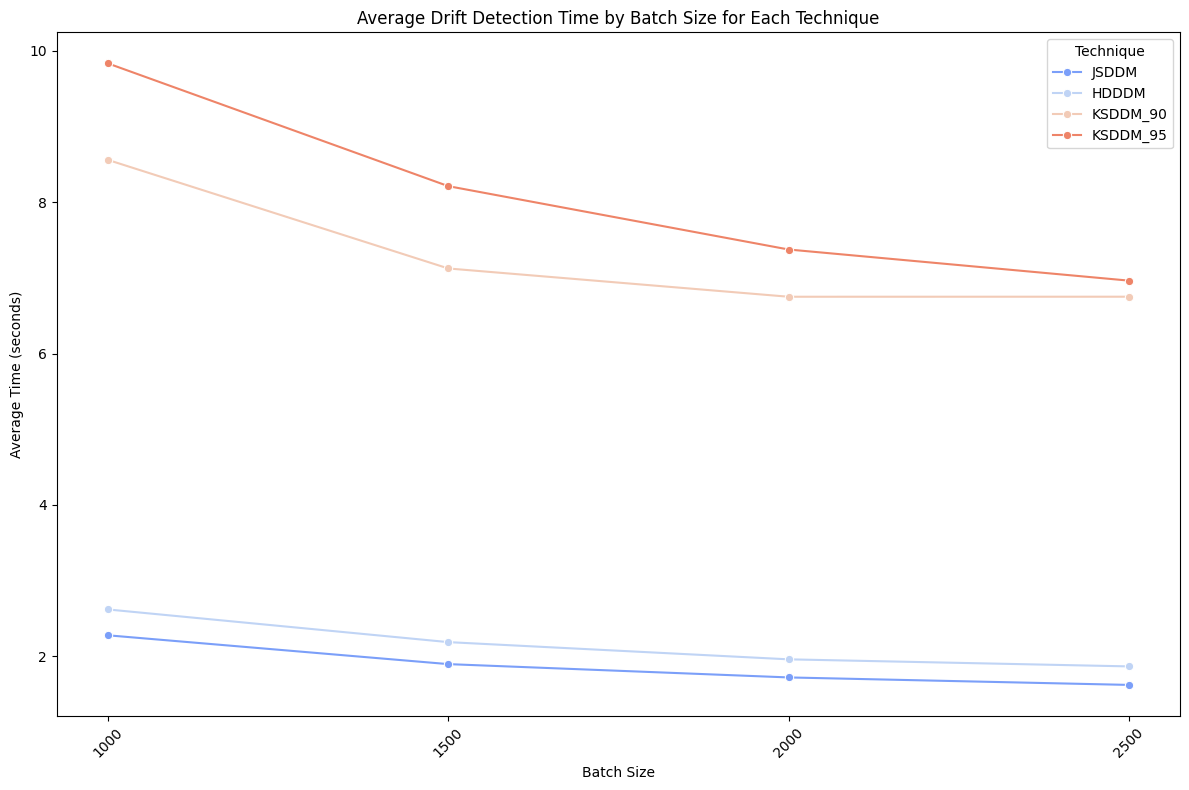

In [45]:
plt.figure(figsize=(12, 8))
sns.lineplot(
    data=batch_size_ranking,
    x='batch_size',
    y='duration_seconds',
    hue='technique',
    marker='o',
    palette='coolwarm'
)
plt.title('Average Drift Detection Time by Batch Size for Each Technique')
plt.xlabel('Batch Size')
plt.ylabel('Average Time (seconds)')
plt.xticks(rotation=45)
plt.legend(title='Technique')
plt.tight_layout()
plt.savefig('./images/average_time_by_batch_size_per_technique.png')
plt.show()

In [46]:
drift_detection_data.columns

Index(['dataset', 'batch_size', 'technique', 'phase', 'duration_seconds',
       'type'],
      dtype='object')

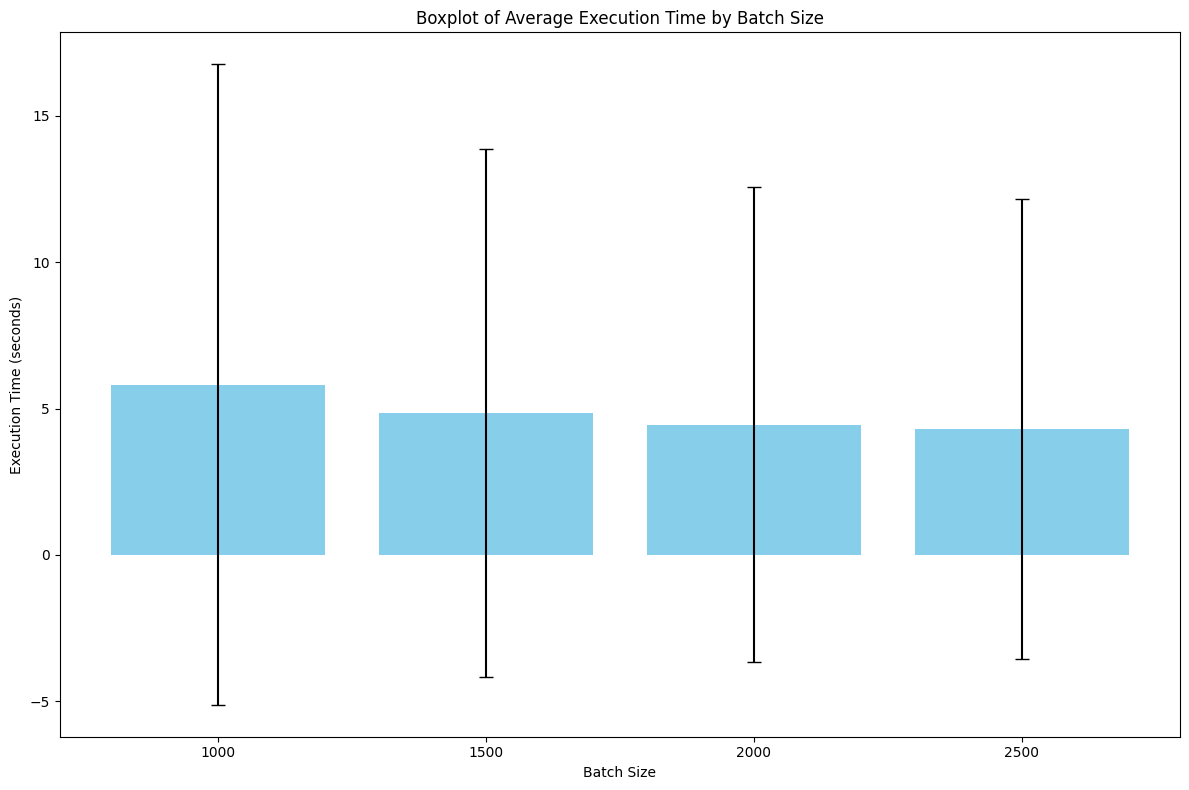

In [47]:
# Create a boxplot for average execution time by batch size
plt.figure(figsize=(12, 8))

# Calculate mean execution time per batch size
# Calculate standard deviation per batch size
batch_stds = drift_detection_data[drift_detection_data['batch_size'] != 'ALL'].groupby('batch_size')['duration_seconds'].std()
batch_means = drift_detection_data[drift_detection_data['batch_size'] != 'ALL'].groupby('batch_size')['duration_seconds'].mean()
plt.bar(batch_means.index, batch_means.values, yerr=batch_stds.values, color='skyblue', capsize=5)

# plt.bar(batch_means.index, batch_means.values, color='skyblue')
plt.title('Boxplot of Average Execution Time by Batch Size')


plt.xlabel('Batch Size')
plt.ylabel('Execution Time (seconds)')
plt.tight_layout()
plt.show()

In [48]:
batch_stds.values

array([10.93906474,  9.02675445,  8.1243267 ,  7.85283776])

In [49]:
batch_means.values

array([5.82326251, 4.8559858 , 4.45234892, 4.30157671])

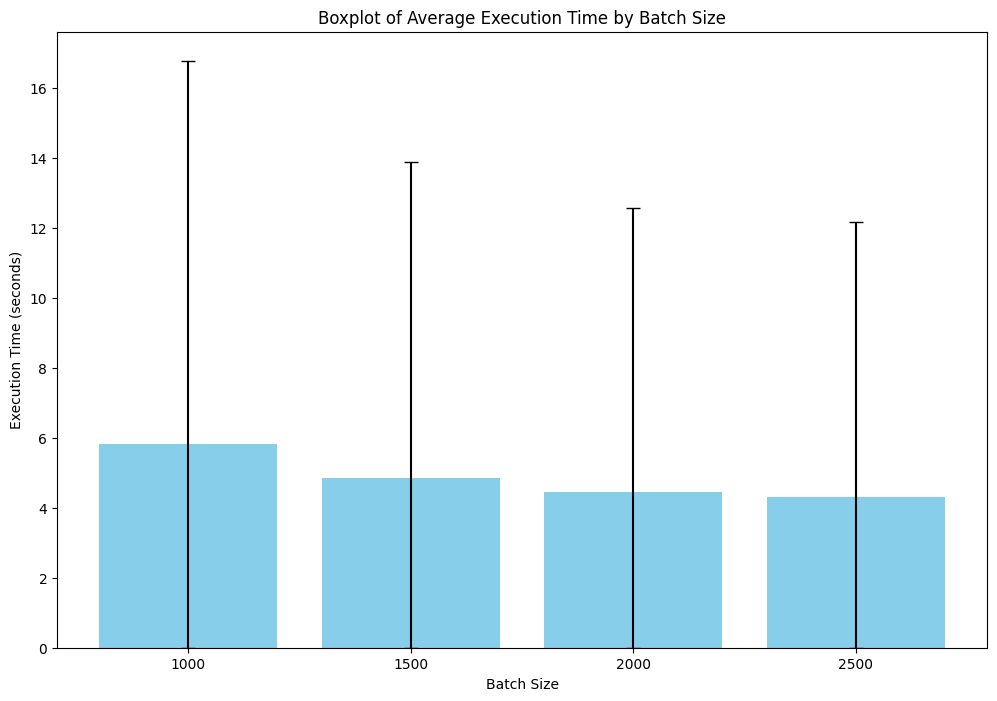

In [50]:
# Set lower error to be the min between std and mean (to not go below 0)
lower_errors = np.minimum(batch_stds, batch_means)
upper_errors = batch_stds

asymmetric_error = [lower_errors, upper_errors]

plt.figure(figsize=(12, 8))
plt.bar(batch_means.index, batch_means.values, yerr=asymmetric_error, color='skyblue', capsize=5)
plt.xlabel("Batch Size")
plt.ylabel("Execution Time (seconds)")
plt.title("Boxplot of Average Execution Time by Batch Size")
plt.grid(False)
plt.show()

/var/folders/5f/sx30p29n23d2bq0_yfm62z4h0000gn/T/ipykernel_2434/2067980356.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=drift_detection_data[drift_detection_data['batch_size'] != 'ALL'],


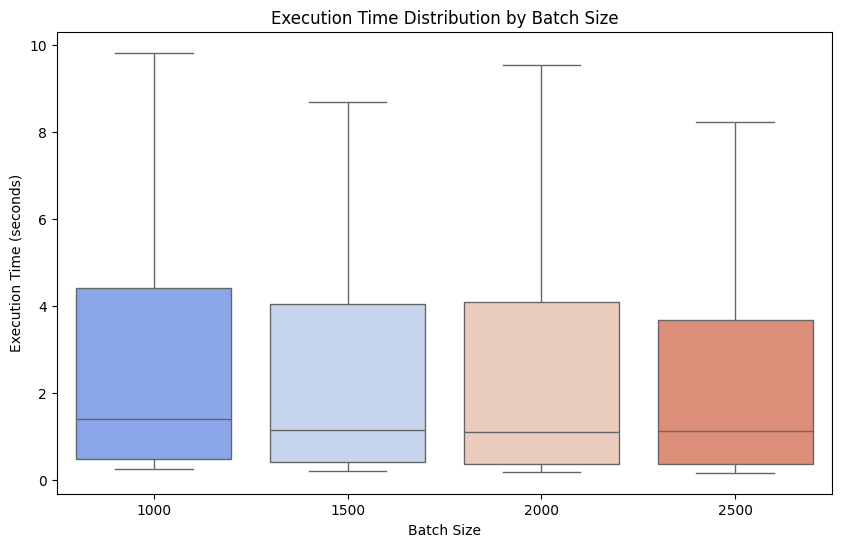

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(data=drift_detection_data[drift_detection_data['batch_size'] != 'ALL'],
            x='batch_size', y='duration_seconds', palette='coolwarm', showfliers=False)
plt.xlabel("Batch Size")
plt.ylabel("Execution Time (seconds)")
plt.title("Execution Time Distribution by Batch Size")
plt.grid(False)
plt.savefig('./images/execution_time_boxplot_single_run.png')
plt.show()


/var/folders/5f/sx30p29n23d2bq0_yfm62z4h0000gn/T/ipykernel_2434/3756494445.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=drift_detection_data[drift_detection_data['batch_size'] != 'ALL'],


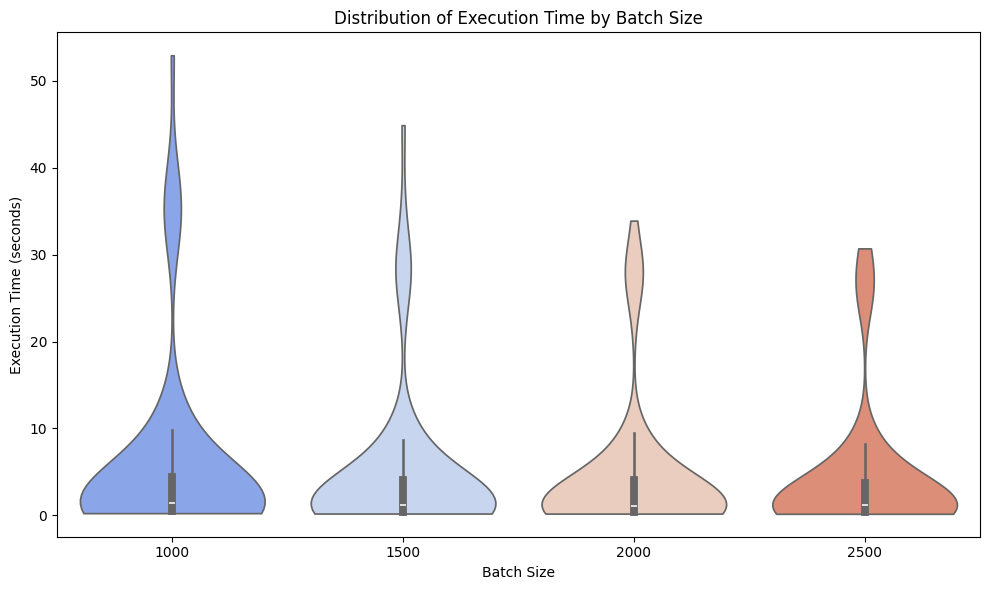

In [ ]:
plt.figure(figsize=(10, 6))


sns.violinplot(data=drift_detection_data[drift_detection_data['batch_size'] != 'ALL'],
               x='batch_size', y='duration_seconds', palette='coolwarm', cut=0)

plt.title("Distribution of Execution Time by Batch Size")
plt.xlabel("Batch Size")
plt.ylabel("Execution Time (seconds)")
# plt.legend(title="Technique", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('ViolinBatchSizePerformanceMultiRun')
plt.show()